# 3. Ciencia de Datos Financiera: Ingeniería, *Feature Engineering* y Construcción de Variables

A diferencia de un conjunto de datos tabular genérico, los datos financieros son series de tiempo con características propias (no estacionariedad, autocorrelación, colas pesadas, baja relación señal-ruido) que exigen un tratamiento cuidadoso antes de alimentar cualquier modelo de *machine learning*.

A lo largo del cuaderno desarrollaremos ejercicios prácticos que cubren tres bloques temáticos:

1. **Ingeniería y procesamiento de datos financieros**: fuentes de datos, limpieza, valores atípicos, remuestreo temporal e integración de múltiples fuentes.
2. **Feature Engineering para modelos de ML aplicados a finanzas**: fuga de información temporal, variables rezagadas y móviles, partición cronológica, escalado y codificación de variables.
3. **Construcción de variables financieras**: retornos, volatilidad, indicadores técnicos (SMA, EMA, MACD, RSI, Bandas de Bollinger), *drawdown* y ratio de Sharpe.

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

np.random.seed(42)

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 1. Ingeniería y Procesamiento de Datos Financieros

### 1.1 Fuentes de datos financieros

Antes de programar, es útil ubicar de dónde provienen los datos con los que trabajaremos. En la práctica, un proyecto de ciencia de datos en aplicaciones financieras combina varias fuentes:

| Tipo de dato | Ejemplos | Frecuencia típica |
|---|---|---|
| **Precios de mercado** | Precio de apertura, máximo, mínimo, cierre y volumen (OHLCV) de acciones, bonos, ETFs, criptoactivos | Intradía, diaria |
| **Datos fundamentales** | Estados financieros, utilidades, ratios (P/E, ROE) | Trimestral, anual |
| **Datos macroeconómicos** | Tasas de interés, inflación, tipo de cambio, PIB | Mensual, trimestral |
| **Datos alternativos** | Noticias, sentimiento en redes sociales, tráfico web, datos satelitales | Variable |

Cada una de estas fuentes llega con su propia frecuencia, calidad y posibles errores. El primer trabajo de la ciencia de datos financiera **no es modelar, es procesar**.

### 1.2 Simulación de una serie de precios OHLCV

Simulamos el precio de cierre de un activo con un Movimiento Browniano Geométrico:

$$S_t = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

donde $\mu$ es el retorno esperado anualizado, $\sigma$ la volatilidad anualizada y $W_t$ un proceso de Wiener (incrementos normales independientes). A partir del cierre simulado, construimos de forma consistente el resto de columnas OHLCV (apertura, máximo, mínimo y volumen).

In [2]:
def simular_ohlcv(precio_inicial, mu, sigma, n_dias, fecha_inicio, semilla=None):
    rng = np.random.default_rng(semilla)
    dt = 1 / 252  # un día bursátil como fracción de año

    fechas = pd.bdate_range(start=fecha_inicio, periods=n_dias)  # solo días hábiles

    incrementos = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rng.standard_normal(n_dias)
    cierre = precio_inicial * np.exp(np.cumsum(incrementos))

    apertura = np.empty(n_dias)
    apertura[0] = precio_inicial
    apertura[1:] = cierre[:-1] * (1 + rng.normal(0, 0.001, n_dias - 1))  # pequeño gap respecto al cierre previo

    ruido_rango = np.abs(rng.normal(0, sigma * np.sqrt(dt), n_dias))
    maximo = np.maximum(apertura, cierre) * (1 + ruido_rango)
    minimo = np.minimum(apertura, cierre) * (1 - ruido_rango)

    volumen = rng.lognormal(mean=13, sigma=0.4, size=n_dias).astype(int)

    return pd.DataFrame({
        "Fecha": fechas,
        "Open": apertura,
        "High": maximo,
        "Low": minimo,
        "Close": cierre,
        "Volume": volumen,
    })

df = simular_ohlcv(precio_inicial=100, mu=0.08, sigma=0.28, n_dias=756, fecha_inicio="2023-01-02", semilla=42)
df.head()

,Fecha,Open,High,Low,Close,Volume
0,2023-01-02,100.000000,101.527372,99.033192,100.555196,406073
1,2023-01-03,100.462600,102.049607,97.183604,98.743453,211391
2,2023-01-04,98.827881,103.601238,95.345977,100.075382,368725
3,2023-01-05,100.139393,104.785703,97.167912,101.765956,522587
4,2023-01-06,101.810992,102.188629,97.974616,98.339375,286021


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Fecha   756 non-null    datetime64[us]
 1   Open    756 non-null    float64       
 2   High    756 non-null    float64       
 3   Low     756 non-null    float64       
 4   Close   756 non-null    float64       
 5   Volume  756 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 35.6 KB


### 1.3 Limpieza de datos: tipos, valores faltantes y duplicados

En un flujo real, los datos casi nunca llegan tan limpios como en la celda anterior. Es común encontrar:

- Columnas de fecha almacenadas como texto en lugar de `datetime`.
- Días faltantes (feriados bursátiles reportados de forma inconsistente por el proveedor).
- Filas duplicadas por errores de concatenación de múltiples descargas.
- Un índice que no queda ordenado cronológicamente.


In [4]:
# ── Simulación de datos "sucios" ───────────────────────────────────────────
df_sucio = df.copy()
df_sucio["Fecha"] = df_sucio["Fecha"].astype(str)          # fecha como texto
df_sucio = pd.concat([df_sucio, df_sucio.iloc[[10]]], ignore_index=True)  # fila duplicada
idx_faltantes = np.random.choice(df_sucio.index[:-1], size=8, replace=False)
df_sucio.loc[idx_faltantes, "Close"] = np.nan               # valores faltantes en Close
df_sucio = df_sucio.sample(frac=1, random_state=1).reset_index(drop=True)  # se desordena

print("Duplicados:", df_sucio.duplicated().sum())
print("Faltantes por columna:\n", df_sucio.isna().sum())
print("Tipo de dato de 'Fecha':", df_sucio["Fecha"].dtype)

Duplicados: 1
Faltantes por columna:
 Fecha     0
Open      0
High      0
Low       0
Close     8
Volume    0
dtype: int64
Tipo de dato de 'Fecha': str


In [5]:
# ── Limpieza ────────────────────────────────────────────────────────────
df_limpio = (
    df_sucio
    .drop_duplicates()
    .assign(Fecha=lambda d: pd.to_datetime(d["Fecha"]))
    .sort_values("Fecha")
    .set_index("Fecha")
)

# Los precios de cierre faltantes se imputan hacia adelante: en un día sin
# información nueva, el último precio conocido sigue siendo la mejor referencia
# (a diferencia de, por ejemplo, imputar con la media de toda la serie).
df_limpio["Close"] = df_limpio["Close"].ffill()

print("Faltantes tras la limpieza:", df_limpio["Close"].isna().sum())
print("¿Índice ordenado y monótono?", df_limpio.index.is_monotonic_increasing)
df_limpio.head()

Faltantes tras la limpieza: 0
¿Índice ordenado y monótono? True


,Open,High,Low,Close,Volume
Fecha,,,,,
2023-01-02,100.000000,101.527372,99.033192,100.555196,406073
2023-01-03,100.462600,102.049607,97.183604,98.743453,211391
2023-01-04,98.827881,103.601238,95.345977,100.075382,368725
2023-01-05,100.139393,104.785703,97.167912,101.765956,522587
2023-01-06,101.810992,102.188629,97.974616,98.339375,286021


### 1.4 Detección y tratamiento de valores atípicos

Los retornos financieros tienen **colas pesadas**: eventos extremos (caídas o subidas fuertes) son más frecuentes de lo que predeciría una distribución normal. Esto implica una diferencia clave frente a otros dominios: **un valor atípico no siempre es un error de captura de datos**, puede ser una crisis, un anuncio corporativo o un evento macro genuino. Por eso, en finanzas se prefiere **detectar y documentar** los atípicos antes de eliminarlos automáticamente.

Usamos el método de puntuación $z$ sobre los retornos diarios:

$$z_t = \frac{r_t - \bar{r}}{s_r}$$

y marcamos como atípico cualquier observación con $|z_t| > 3$.

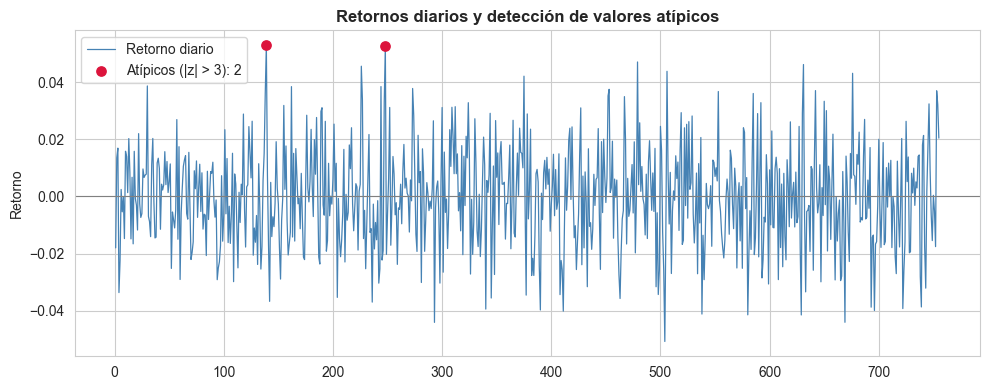

In [6]:
retornos = df["Close"].pct_change().dropna()
z_scores = (retornos - retornos.mean()) / retornos.std()
atipicos = z_scores.abs() > 3

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(retornos.index, retornos.values, color="steelblue", linewidth=0.9, label="Retorno diario")
ax.scatter(retornos.index[atipicos], retornos.values[atipicos],
           color="crimson", s=45, zorder=5, label=f"Atípicos (|z| > 3): {atipicos.sum()}")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Retornos diarios y detección de valores atípicos")
ax.set_ylabel("Retorno")
ax.legend()
plt.tight_layout()
plt.show()

### 1.5 Remuestreo temporal (*resampling*)

Con frecuencia necesitamos cambiar la granularidad de la serie: pasar de datos diarios a semanales o mensuales para reducir ruido, alinear frecuencias entre activos o construir variables de más largo plazo. El remuestreo de una serie OHLCV **no es un simple promedio**: cada columna requiere una regla de agregación distinta.

| Columna | Regla de agregación |
|---|---|
| `Open` | primer valor del periodo |
| `High` | máximo del periodo |
| `Low` | mínimo del periodo |
| `Close` | último valor del periodo |
| `Volume` | suma del periodo |

In [7]:
df_semanal = df.set_index("Fecha").resample("W").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum",
})

df_mensual = df.set_index("Fecha").resample("ME").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum",
})

print(f"Diario: {len(df)} filas  |  Semanal: {len(df_semanal)} filas  |  Mensual: {len(df_mensual)} filas")
df_semanal.head()

Diario: 756 filas  |  Semanal: 152 filas  |  Mensual: 35 filas


,Open,High,Low,Close,Volume
Fecha,,,,,
2023-01-08,100.000000,104.785703,95.345977,98.339375,1794797
2023-01-15,98.462267,99.703801,92.294122,94.405565,2066430
2023-01-22,94.237182,102.082764,89.666704,100.176442,2666288
2023-01-29,100.349647,103.112498,94.016820,99.165575,2810354
2023-02-05,99.185686,103.383707,95.725133,98.850864,3215071


### 1.6 Integración de múltiples fuentes: precios de mercado + datos macro

Un modelo financiero rara vez usa una sola fuente. Simulamos una **tasa de interés de referencia** publicada mensualmente y la integramos con la serie diaria de precios. Aquí aparece un principio que retomaremos en la siguiente sección: los datos macro se publican con **rezago y baja frecuencia**, así que al integrarlos con `merge_asof` + `ffill` debemos asegurarnos de solo propagar hacia adelante el último dato ya disponible en cada fecha, nunca hacia atrás.

In [8]:
fechas_macro = pd.date_range("2023-01-01", periods=30, freq="MS")
tasa_interes = 0.10 + np.cumsum(np.random.normal(0, 0.0015, len(fechas_macro)))
df_macro = pd.DataFrame({"Fecha": fechas_macro, "tasa_interes": tasa_interes})

df_integrado = pd.merge_asof(
    df.sort_values("Fecha"),
    df_macro.sort_values("Fecha"),
    on="Fecha",
    direction="backward",   # solo usa información macro ya publicada en esa fecha
)

df_integrado = df_integrado.set_index("Fecha")
df_integrado[["Close", "tasa_interes"]].head(3)

,Close,tasa_interes
Fecha,,
2023-01-02,100.555196,0.102095
2023-01-03,98.743453,0.102095
2023-01-04,100.075382,0.102095


## 2. Feature Engineering para Modelos de Machine Learning en Finanzas

*Feature engineering* es el proceso de transformar datos crudos en variables que un modelo pueda aprovechar. En finanzas, este proceso tiene una restricción que no es negociable: **el orden temporal**.

### 2.1 Fuga de información temporal (*data leakage*): la regla de oro

> En el instante $t$, un modelo **solo** puede usar información disponible hasta $t$. Nunca información de $t+1$ en adelante.

Violar esta regla es el error más común —y más grave— al construir modelos financieros. Ejemplos típicos de fuga:

- Calcular una media o desviación estándar usando **todo** el conjunto de datos (incluido el futuro) para escalar variables.
- Dividir entrenamiento/prueba de forma **aleatoria** en una serie de tiempo, permitiendo que el modelo "vea" el futuro durante el entrenamiento.
- Usar como variable un dato macro con la fecha de **referencia** del periodo en lugar de la fecha real de **publicación** (p. ej., el PIB del primer trimestre se publica semanas después de terminado el trimestre).

Estos casos generan modelos con métricas excelentes en el desarrollo... y un desempeño irreconocible en producción.

### 2.2 Variables rezagadas (*lags*) y estadísticas móviles (*rolling*)

Dos familias de variables cubren la mayoría de casos de uso:

- **Rezagos**: $x_{t-k}$, el valor de una variable $k$ periodos atrás.
- **Ventanas móviles**: estadísticos (media, desviación estándar, mínimo, máximo) calculados sobre una ventana de los últimos $w$ periodos, por ejemplo $\text{MA}_w(t) = \frac{1}{w}\sum_{i=0}^{w-1} x_{t-i}$.

Ambas son, por construcción, seguras frente a la fuga de información: solo usan el pasado.

In [9]:
feat = df_integrado.copy()
feat["retorno"] = feat["Close"].pct_change()

# Variables rezagadas del retorno
for k in [1, 2, 5]:
    feat[f"retorno_lag{k}"] = feat["retorno"].shift(k)

# Estadísticas móviles (usan solo información pasada gracias a .shift(1) antes de .rolling)
for w in [5, 10, 20]:
    feat[f"media_movil_ret_{w}"] = feat["retorno"].shift(1).rolling(w).mean()
    feat[f"vol_movil_ret_{w}"] = feat["retorno"].shift(1).rolling(w).std()

feat[["Close", "retorno", "retorno_lag1", "media_movil_ret_5", "vol_movil_ret_5"]].dropna().head()

,Close,retorno,retorno_lag1,media_movil_ret_5,vol_movil_ret_5
Fecha,,,,,
2023-01-10,96.354580,0.002420,-0.022548,-0.008771,0.022636
2023-01-11,95.834125,-0.005401,0.002420,-0.004684,0.022392
2023-01-12,95.821242,-0.000134,-0.005401,-0.008462,0.020029
2023-01-13,94.405565,-0.014774,-0.000134,-0.011867,0.015597
2023-01-16,95.896841,0.015796,-0.014774,-0.008088,0.010425


### 2.3 Partición temporal correcta: *split* cronológico y validación *walk-forward*

En datos tabulares independientes es común hacer `train_test_split` aleatorio. **En series de tiempo esto está prohibido**: si el conjunto de prueba tiene observaciones anteriores al de entrenamiento, el modelo aprende del futuro para predecir el pasado, lo cual no ocurrirá jamás en producción.

La alternativa correcta:

1. **Partición cronológica simple**: los primeros $p\%$ de las fechas para entrenar, el resto para probar.
2. **Validación *walk-forward* (`TimeSeriesSplit`)**: múltiples particiones donde el conjunto de entrenamiento crece hacia adelante y el de prueba siempre sigue **después** en el tiempo, simulando cómo se reentrenaría el modelo periodo a periodo en la vida real.

Fecha de corte: 2025-04-25  →  604 obs. entrenamiento / 152 obs. prueba


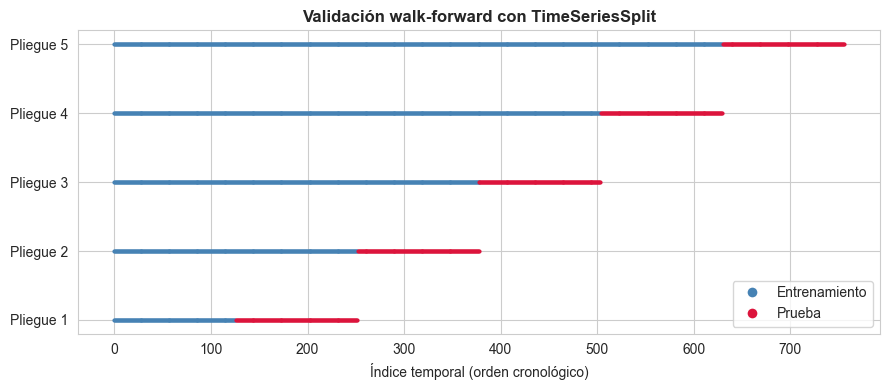

In [10]:
# ── 1) Partición cronológica simple (80% / 20%) ────────────────────────────
corte = int(len(feat) * 0.8)
fecha_corte = feat.index[corte]
print(f"Fecha de corte: {fecha_corte.date()}  →  {corte} obs. entrenamiento / {len(feat) - corte} obs. prueba")

# ── 2) Validación walk-forward con TimeSeriesSplit ─────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(9, 4))
for i, (idx_train, idx_test) in enumerate(tscv.split(feat)):
    ax.scatter(idx_train, [i] * len(idx_train), color="steelblue", s=4)
    ax.scatter(idx_test, [i] * len(idx_test), color="crimson", s=4)

ax.set_yticks(range(5))
ax.set_yticklabels([f"Pliegue {i+1}" for i in range(5)])
ax.set_xlabel("Índice temporal (orden cronológico)")
ax.set_title("Validación walk-forward con TimeSeriesSplit")
ax.legend(handles=[
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", label="Entrenamiento", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson", label="Prueba", markersize=8),
])
plt.tight_layout()
plt.show()

### 2.4 Escalado de variables sin fuga de información

Al igual que con el *split*, el escalador (`StandardScaler`, `MinMaxScaler`, etc.) debe **ajustarse (`fit`) únicamente con el conjunto de entrenamiento** y luego aplicarse (`transform`) tanto a entrenamiento como a prueba. Ajustarlo con todos los datos filtra estadísticos del futuro (media y desviación estándar del periodo de prueba) hacia el entrenamiento.

In [11]:
cols_numericas = ["retorno_lag1", "media_movil_ret_5", "vol_movil_ret_5", "tasa_interes"]
feat_valid = feat.dropna(subset=cols_numericas)

X_train_ejemplo = feat_valid.loc[:fecha_corte, cols_numericas]
X_test_ejemplo = feat_valid.loc[fecha_corte:, cols_numericas]

escalador = StandardScaler().fit(X_train_ejemplo)  # ajustado SOLO con entrenamiento

X_train_esc = pd.DataFrame(escalador.transform(X_train_ejemplo), columns=cols_numericas)
X_test_esc = pd.DataFrame(escalador.transform(X_test_ejemplo), columns=cols_numericas)

print("Media en entrenamiento escalado (≈0):\n", X_train_esc.mean().round(3).to_dict())
print("\nMedia en prueba escalada (no necesariamente 0, y así debe ser):\n", X_test_esc.mean().round(3).to_dict())

Media en entrenamiento escalado (≈0):
 {'retorno_lag1': -0.0, 'media_movil_ret_5': -0.0, 'vol_movil_ret_5': 0.0, 'tasa_interes': -0.0}

Media en prueba escalada (no necesariamente 0, y así debe ser):
 {'retorno_lag1': -0.089, 'media_movil_ret_5': -0.216, 'vol_movil_ret_5': 0.249, 'tasa_interes': 0.908}


### 2.5 Codificación de variables categóricas y cíclicas

Variables como el día de la semana o el mes son categóricas, pero también **cíclicas** (después del viernes viene el lunes, después de diciembre viene enero). Codificarlas como enteros simples (0, 1, 2, ...) le sugiere al modelo una distancia falsa entre, por ejemplo, diciembre (11) y enero (0). La codificación seno/coseno preserva la continuidad del ciclo:

$$x_{\sin} = \sin\left(\frac{2\pi \cdot x}{T}\right), \qquad x_{\cos} = \cos\left(\frac{2\pi \cdot x}{T}\right)$$

También construimos una variable de **régimen de mercado** (alcista/bajista) a partir de la posición del precio respecto a su media móvil de 50 días, un ejemplo de variable categórica derivada de datos numéricos.

In [12]:
feat["dia_semana"] = feat.index.dayofweek
feat["dia_semana_sin"] = np.sin(2 * np.pi * feat["dia_semana"] / 5)
feat["dia_semana_cos"] = np.cos(2 * np.pi * feat["dia_semana"] / 5)

feat["mes"] = feat.index.month
feat["mes_sin"] = np.sin(2 * np.pi * feat["mes"] / 12)
feat["mes_cos"] = np.cos(2 * np.pi * feat["mes"] / 12)

sma_50 = feat["Close"].shift(1).rolling(50).mean()
feat["regimen_alcista"] = (feat["Close"].shift(1) > sma_50).astype(int)

feat[["dia_semana", "dia_semana_sin", "dia_semana_cos", "regimen_alcista"]].dropna().head()

,dia_semana,dia_semana_sin,dia_semana_cos,regimen_alcista
Fecha,,,,
2023-01-02,0,0.000000,1.000000,0
2023-01-03,1,0.951057,0.309017,0
2023-01-04,2,0.587785,-0.809017,0
2023-01-05,3,-0.587785,-0.809017,0
2023-01-06,4,-0.951057,0.309017,0


### 2.6 Selección preliminar de variables

Antes de construir un modelo, una revisión rápida de correlaciones ayuda a detectar variables redundantes (por ejemplo, dos medias móviles muy cercanas en ventana) y a tener una primera intuición sobre qué variables se relacionan con el retorno futuro.

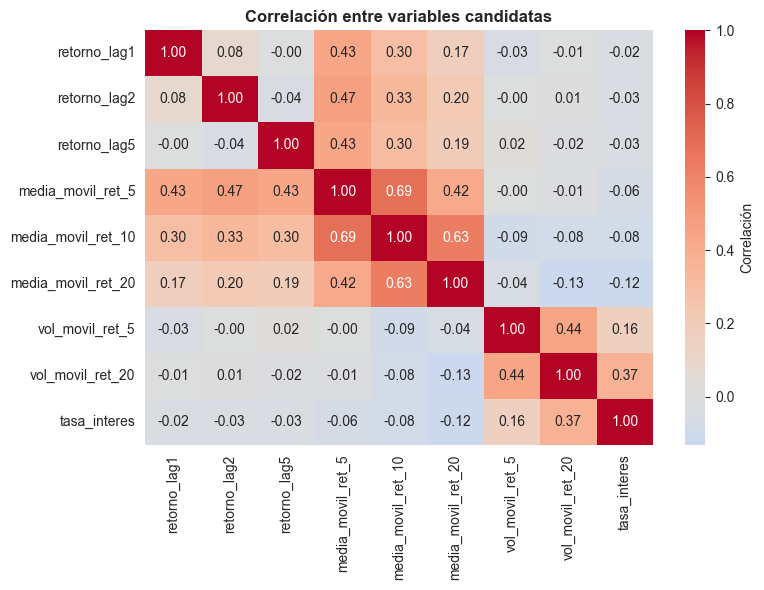

In [13]:
cols_exploracion = ["retorno_lag1", "retorno_lag2", "retorno_lag5",
                     "media_movil_ret_5", "media_movil_ret_10", "media_movil_ret_20",
                     "vol_movil_ret_5", "vol_movil_ret_20", "tasa_interes"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feat[cols_exploracion].dropna().corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Correlación"})
ax.set_title("Correlación entre variables candidatas")
plt.tight_layout()
plt.show()

## 3. Construcción de Variables Financieras

Además de las técnicas genéricas de *feature engineering*, el análisis financiero cuenta con un vocabulario propio de variables construidas a partir de los precios: **retornos, riesgo, tendencia, momentum y volumen**. Estas variables encapsulan décadas de práctica en análisis técnico y gestión de riesgo, y son insumos habituales para modelos de ML en finanzas.

### 3.1 Retornos simples y logarítmicos

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} \qquad \qquad r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Los retornos logarítmicos son **aditivos en el tiempo** ($r_{t_1 \to t_3} = r_{t_1 \to t_2} + r_{t_2 \to t_3}$), lo que los hace convenientes para agregaciones multi-periodo, mientras que los retornos simples son los que efectivamente se ganan o pierden en una inversión.

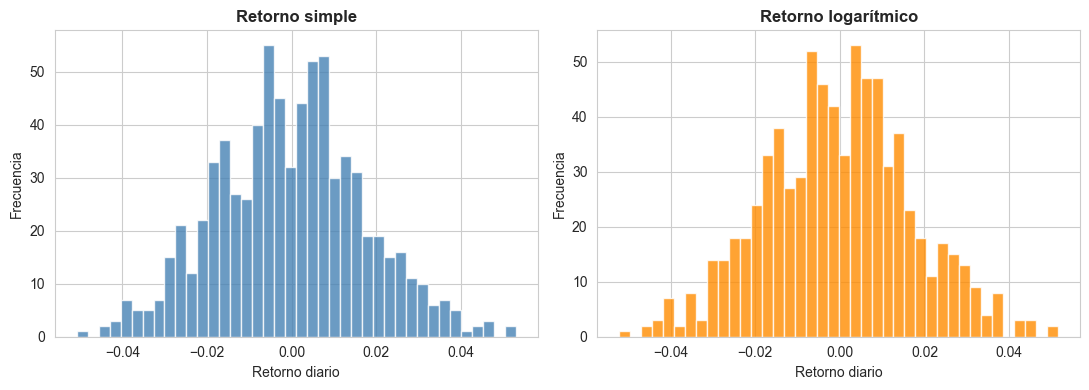

Diferencia media entre ambos retornos: 0.000152


In [14]:
precios = df.set_index("Fecha")["Close"]

retorno_simple = precios.pct_change()
retorno_log = np.log(precios / precios.shift(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(retorno_simple.dropna(), bins=40, color="steelblue", alpha=0.8)
axes[0].set_title("Retorno simple")
axes[1].hist(retorno_log.dropna(), bins=40, color="darkorange", alpha=0.8)
axes[1].set_title("Retorno logarítmico")
for ax in axes:
    ax.set_xlabel("Retorno diario")
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Diferencia media entre ambos retornos: {(retorno_simple - retorno_log).mean():.6f}")

### 3.2 Volatilidad histórica

La volatilidad es la medida de riesgo más usada en finanzas: la desviación estándar de los retornos, anualizada multiplicando por $\sqrt{252}$ (número aproximado de días bursátiles al año):

$$\sigma_{\text{anual}}(t) = \sigma_{w}(t) \cdot \sqrt{252}, \qquad \sigma_w(t) = \text{desviación estándar móvil de los retornos en una ventana } w$$

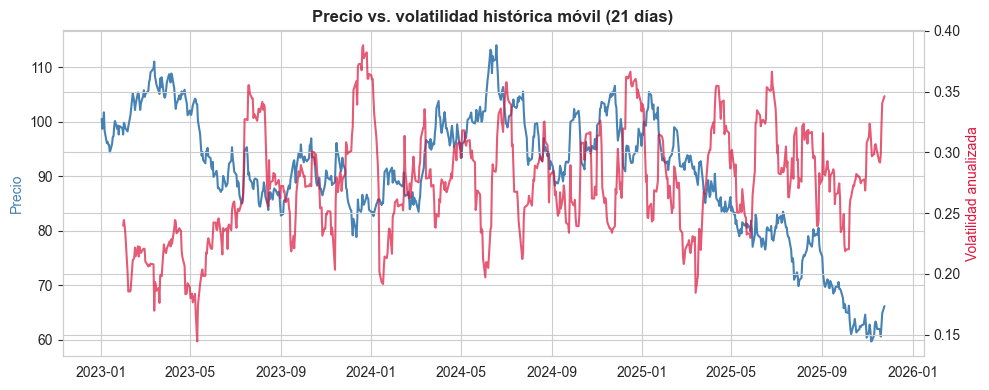

In [15]:
vol_21 = retorno_log.rolling(21).std() * np.sqrt(252)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(precios.index, precios.values, color="steelblue", label="Precio de cierre")
ax1.set_ylabel("Precio", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(vol_21.index, vol_21.values, color="crimson", alpha=0.7, label="Volatilidad anualizada (21d)")
ax2.set_ylabel("Volatilidad anualizada", color="crimson")

ax1.set_title("Precio vs. volatilidad histórica móvil (21 días)")
plt.tight_layout()
plt.show()

### 3.3 Indicadores de tendencia: medias móviles y MACD

- **Media móvil simple (SMA)**: promedio de los últimos $w$ precios.
- **Media móvil exponencial (EMA)**: promedio ponderado que da más peso a las observaciones recientes, con factor de suavizado $\alpha = 2/(w+1)$.
- **MACD** (*Moving Average Convergence Divergence*): $\text{MACD}_t = \text{EMA}_{12}(t) - \text{EMA}_{26}(t)$, junto con una línea de señal $\text{EMA}_9(\text{MACD})$. Cruces entre el MACD y su señal se interpretan como cambios de tendencia.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_83248/1335232305.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


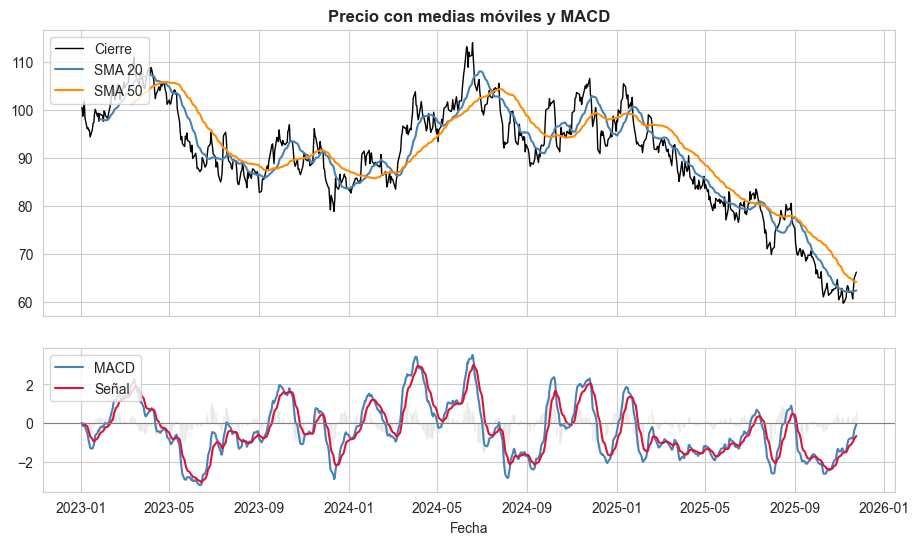

In [16]:
sma_20 = precios.rolling(20).mean()
sma_50 = precios.rolling(50).mean()
ema_12 = precios.ewm(span=12, adjust=False).mean()
ema_26 = precios.ewm(span=26, adjust=False).mean()
macd = ema_12 - ema_26
señal_macd = macd.ewm(span=9, adjust=False).mean()

fig = plt.figure(figsize=(11, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.15)

ax0 = fig.add_subplot(gs[0])
ax0.plot(precios.index, precios.values, color="black", linewidth=1, label="Cierre")
ax0.plot(sma_20.index, sma_20.values, color="steelblue", label="SMA 20")
ax0.plot(sma_50.index, sma_50.values, color="darkorange", label="SMA 50")
ax0.set_title("Precio con medias móviles y MACD")
ax0.legend(loc="upper left")
ax0.tick_params(labelbottom=False)

ax1 = fig.add_subplot(gs[1], sharex=ax0)
histograma_macd = macd - señal_macd
ax1.plot(macd.index, macd.values, color="steelblue", label="MACD")
ax1.plot(señal_macd.index, señal_macd.values, color="crimson", label="Señal")
ax1.bar(macd.index, histograma_macd, color="grey", alpha=0.4, width=1.0)
ax1.axhline(0, color="grey", linewidth=0.8)
ax1.legend(loc="upper left")
ax1.set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### 3.4 Osciladores de momentum: RSI

El **Índice de Fuerza Relativa (RSI)** mide la magnitud relativa de las ganancias frente a las pérdidas recientes, oscilando entre 0 y 100:

$$\text{RSI}_t = 100 - \frac{100}{1 + RS_t}, \qquad RS_t = \frac{\text{promedio móvil de ganancias}}{\text{promedio móvil de pérdidas}}$$

Valores por encima de 70 suelen interpretarse como sobrecompra, y por debajo de 30 como sobreventa.

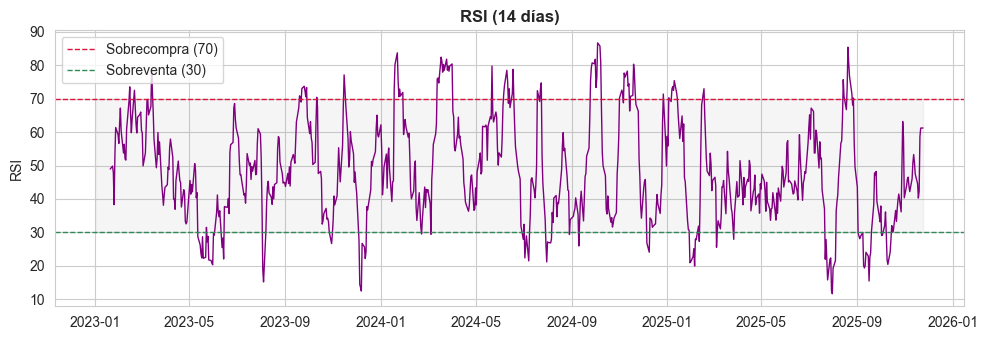

In [17]:
def calcular_rsi(serie_precios, ventana=14):
    delta = serie_precios.diff()
    ganancia = delta.clip(lower=0)
    perdida = -delta.clip(upper=0)

    ganancia_media = ganancia.rolling(ventana).mean()
    perdida_media = perdida.rolling(ventana).mean()

    rs = ganancia_media / perdida_media
    return 100 - (100 / (1 + rs))

rsi_14 = calcular_rsi(precios, ventana=14)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rsi_14.index, rsi_14.values, color="purple", linewidth=1)
ax.axhline(70, color="crimson", linestyle="--", linewidth=1, label="Sobrecompra (70)")
ax.axhline(30, color="seagreen", linestyle="--", linewidth=1, label="Sobreventa (30)")
ax.fill_between(rsi_14.index, 30, 70, color="grey", alpha=0.08)
ax.set_title("RSI (14 días)")
ax.set_ylabel("RSI")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 3.5 Bandas de Bollinger

Combinan tendencia y volatilidad: una banda central (SMA) y dos bandas a $k$ desviaciones estándar móviles de distancia:

$$\text{Banda superior} = \text{SMA}_w + k\sigma_w, \qquad \text{Banda inferior} = \text{SMA}_w - k\sigma_w$$

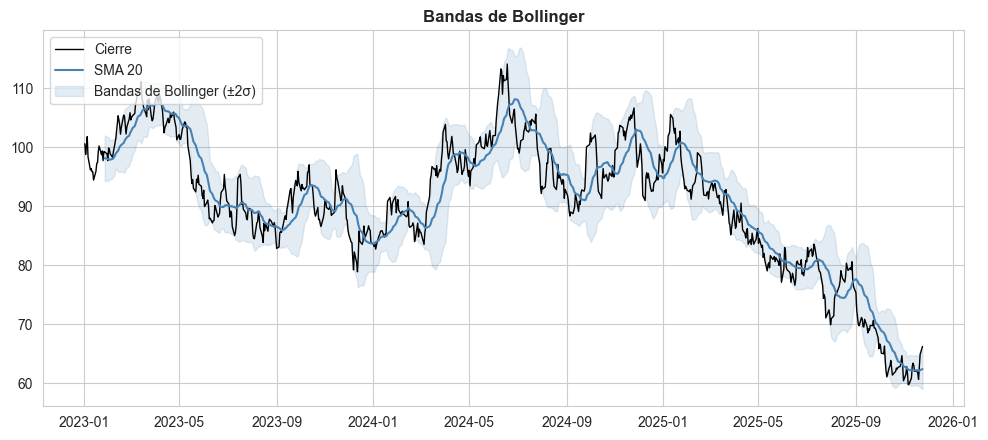

In [18]:
w, k = 20, 2
sma_w = precios.rolling(w).mean()
std_w = precios.rolling(w).std()
banda_sup = sma_w + k * std_w
banda_inf = sma_w - k * std_w

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(precios.index, precios.values, color="black", linewidth=1, label="Cierre")
ax.plot(sma_w.index, sma_w.values, color="steelblue", label="SMA 20")
ax.fill_between(precios.index, banda_inf, banda_sup, color="steelblue", alpha=0.15, label="Bandas de Bollinger (±2σ)")
ax.set_title("Bandas de Bollinger")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 3.6 *Drawdown* y máximo *drawdown*

El *drawdown* mide la caída porcentual del precio respecto a su máximo histórico previo, una medida de **riesgo de cola** muy usada en gestión de portafolios:

$$\text{DD}_t = \frac{P_t}{\max_{s \le t} P_s} - 1$$

El **máximo drawdown** es el peor valor observado de esta serie: la mayor pérdida que habría sufrido un inversionista que compró en el peor momento posible antes de una caída.

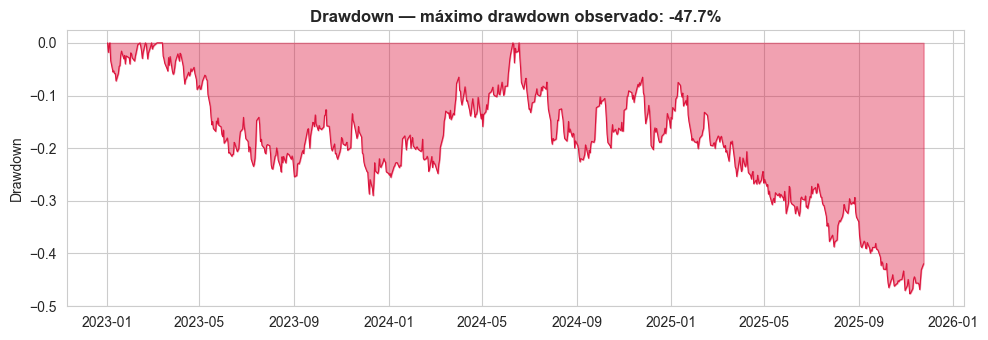

In [19]:
maximo_acumulado = precios.cummax()
drawdown = precios / maximo_acumulado - 1
max_drawdown = drawdown.min()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.fill_between(drawdown.index, drawdown.values, 0, color="crimson", alpha=0.4)
ax.plot(drawdown.index, drawdown.values, color="crimson", linewidth=0.8)
ax.set_title(f"Drawdown — máximo drawdown observado: {max_drawdown:.1%}")
ax.set_ylabel("Drawdown")
plt.tight_layout()
plt.show()

### 3.7 Ratio de Sharpe

Mide el retorno obtenido por unidad de riesgo asumido, comparando el exceso de retorno frente a una tasa libre de riesgo $r_f$ con la volatilidad de esos retornos:

$$\text{Sharpe} = \frac{\bar{R} - r_f}{\sigma_R} \cdot \sqrt{252}$$

In [20]:
r_f_diaria = 0.0  # tasa libre de riesgo diaria, simplificada a 0 para el ejercicio
sharpe_anualizado = (retorno_simple.mean() - r_f_diaria) / retorno_simple.std() * np.sqrt(252)

print(f"Ratio de Sharpe anualizado: {sharpe_anualizado:.2f}")

Ratio de Sharpe anualizado: -0.37


### 3.8 Ejercicio integrador: de las variables construidas a un modelo predictivo

Cerramos el cuaderno integrando **todo lo desarrollado**: usamos las variables de las secciones 1, 2 y 3 para construir una matriz de variables $X$ y una variable objetivo binaria $y$ (¿el retorno del día siguiente será positivo?), respetamos la partición cronológica y el escalado sin fuga de información, y entrenamos dos modelos simples de clasificación a modo ilustrativo.

> Este ejercicio es **pedagógico**: un pipeline de *trading* real exigiría, además, costos de transacción, validación *walk-forward* completa (no un único *split*), y una evaluación económica (no solo de exactitud).

In [21]:
variables = feat.copy()

variables["sma_20"] = variables["Close"].shift(1).rolling(20).mean()
variables["ema_12"] = variables["Close"].shift(1).ewm(span=12, adjust=False).mean()
variables["rsi_14"] = calcular_rsi(variables["Close"].shift(1), ventana=14)
variables["volatilidad_21"] = variables["retorno"].shift(1).rolling(21).std() * np.sqrt(252)
variables["distancia_sma20"] = variables["Close"].shift(1) / variables["sma_20"] - 1

columnas_features = [
    "retorno_lag1", "retorno_lag2", "retorno_lag5",
    "media_movil_ret_5", "media_movil_ret_10", "media_movil_ret_20",
    "vol_movil_ret_5", "vol_movil_ret_20",
    "dia_semana_sin", "dia_semana_cos", "mes_sin", "mes_cos",
    "regimen_alcista", "rsi_14", "volatilidad_21", "distancia_sma20",
    "tasa_interes",
]

variables["objetivo"] = (variables["retorno"].shift(-1) > 0).astype(int)  # ¿sube el precio mañana?

dataset = variables[columnas_features + ["objetivo"]].dropna()

corte = int(len(dataset) * 0.8)
X_train, X_test = dataset[columnas_features].iloc[:corte], dataset[columnas_features].iloc[corte:]
y_train, y_test = dataset["objetivo"].iloc[:corte], dataset["objetivo"].iloc[corte:]

escalador_final = StandardScaler().fit(X_train)
X_train_esc = escalador_final.transform(X_train)
X_test_esc = escalador_final.transform(X_test)

print(f"Observaciones de entrenamiento: {len(X_train)}  |  Observaciones de prueba: {len(X_test)}")
print(f"Proporción de clase positiva (sube) — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Observaciones de entrenamiento: 587  |  Observaciones de prueba: 147
Proporción de clase positiva (sube) — train: 49.91% | test: 44.90%


In [22]:
modelo_logit = LogisticRegression(max_iter=1000).fit(X_train_esc, y_train)
modelo_rf = RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42).fit(X_train, y_train)

for nombre, modelo, X_eval in [("Regresión Logística", modelo_logit, X_test_esc),
                                 ("Random Forest", modelo_rf, X_test)]:
    pred = modelo.predict(X_eval)
    print(f"── {nombre} ──")
    print(f"Exactitud: {accuracy_score(y_test, pred):.2%}")
    print(classification_report(y_test, pred, target_names=["Baja", "Sube"], zero_division=0))

── Regresión Logística ──
Exactitud: 56.46%
              precision    recall  f1-score   support

        Baja       0.61      0.58      0.59        81
        Sube       0.51      0.55      0.53        66

    accuracy                           0.56       147
   macro avg       0.56      0.56      0.56       147
weighted avg       0.57      0.56      0.57       147

── Random Forest ──
Exactitud: 50.34%
              precision    recall  f1-score   support

        Baja       0.56      0.47      0.51        81
        Sube       0.46      0.55      0.50        66

    accuracy                           0.50       147
   macro avg       0.51      0.51      0.50       147
weighted avg       0.51      0.50      0.50       147



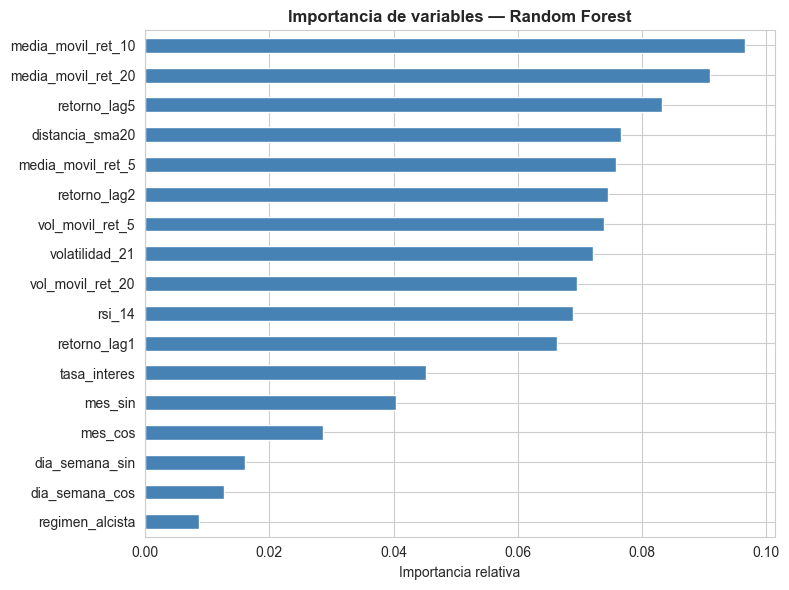

In [23]:
importancias = pd.Series(modelo_rf.feature_importances_, index=columnas_features).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot.barh(ax=ax, color="steelblue")
ax.set_title("Importancia de variables — Random Forest")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

> **Sobre los resultados**: con datos simulados mediante un GBM puro, los retornos futuros son —por construcción— prácticamente independientes de los retornos e indicadores pasados. Es esperable que la exactitud de ambos modelos ronde el 50%, similar al azar. Esto **no es un error**: ilustra un punto central en ciencia de datos financiera, que la señal predictiva real (cuando existe) es históricamente pequeña, ruidosa y costosa de aislar, muy distinta de otros dominios de ML.

## 4. Ejercicios propuestos

Para consolidar los tres bloques temáticos, desarrolla los siguientes ejercicios ampliando el trabajo hecho en este cuaderno:

1. **Datos reales**: descarga precios históricos de un activo real (por ejemplo con la librería `yfinance`) y repite el flujo de limpieza de la sección 1 (tipos, duplicados, faltantes, atípicos). Documenta qué problemas de calidad encontraste que no aparecían en los datos simulados.
2. **Variable de volumen relativo**: construye la variable $\text{vol\_relativo}_t = \text{Volume}_t / \text{media\_movil}_{20}(\text{Volume})_t$ y evalúa si mejora el desempeño del `RandomForestClassifier` de la sección 3.8.
3. **Validación walk-forward completa**: en lugar de un único *split* 80/20, usa `TimeSeriesSplit` (sección 2.3) para entrenar y evaluar el modelo en los 5 pliegues, y compara la exactitud obtenida en cada uno. ¿Es estable a través del tiempo?
4. **Oscilador estocástico**: implementa el indicador %K / %D (estocástico), similar en espíritu al RSI, y agrégalo como variable adicional.
5. **Impacto de la variable macro**: entrena el modelo con y sin la variable `tasa_interes` y compara las métricas. Luego, modifica intencionalmente la integración para introducir fuga de información (usa `direction="forward"` en `merge_asof`) y observa cómo cambian —artificialmente— los resultados.

## 5. Conclusiones

- La ciencia de datos financiera empieza por una **ingeniería de datos rigurosa**: tipos correctos, tratamiento cuidadoso de atípicos y faltantes, y remuestreo e integración de fuentes con distinta frecuencia.
- El *feature engineering* en series de tiempo financieras está gobernado por una restricción no negociable: **nunca usar información del futuro**. Esto afecta el escalado, la partición de datos y la construcción de variables por igual.
- Las variables financieras clásicas (retornos, volatilidad, medias móviles, MACD, RSI, Bandas de Bollinger, *drawdown*, Sharpe) condensan conocimiento de dominio que complementa —y en muchos casos supera en relevancia— a técnicas genéricas de *feature engineering*.

**Referencias para profundizar:**

- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Hilpisch, Y. (2018). *Python for Finance: Mastering Data-Driven Finance* (2.ª ed.). O'Reilly.
- Murphy, J. J. (1999). *Technical Analysis of the Financial Markets*. New York Institute of Finance.